# Description du projet

Ce projet vise à développer un système de prévision de séries temporelles météorologiques, en s’appuyant sur des données historiques de température. L’objectif est de construire, évaluer et comparer plusieurs modèles de prévision, allant des approches statistiques classiques aux méthodes de deep learning, afin d’identifier la solution la plus performante.

Les données utilisées proviennent de l’API  [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api), qui fournit des observations météorologiques historiques issues de modèles de réanalyse combinant différentes sources (stations, satellites, radars). Cette API permet d’obtenir des données fiables même dans des zones peu couvertes par des stations météorologiques.

**Données :**
Le jeu de données est constitué d’une série temporelle de températures à 2 mètres du sol (“Temperature (2 m)”) pour la  ville de **Londres** , identifiée par ses coordonnées géographiques (latitude, longitude).

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
graceannexes_final_project_bihar_path = kagglehub.dataset_download('graceannexes/final-project-bihar')
print('Data source import complete.')


100%|██████████| 2.21M/2.21M [00:00<00:00, 109MB/s]

Extracting files...
Data source import complete.


In [ ]:
!ls /root/.cache/kagglehub/datasets/graceannexes/final-project-bihar/versions/4/2019-2024-01.csv

/root/.cache/kagglehub/datasets/graceannexes/final-project-bihar/versions/4/2019-2024-01.csv


In [ ]:
!pip install keras-tcn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss
from tcn import TCN
from sklearn.model_selection import TimeSeriesSplit
from pandas.plotting import autocorrelation_plot

from util_ts import (baseline_forecast,inverse_transform_multi,plot_model_comparison,
                     create_sequences_multistep,inverse_transform_safe,
                     create_sequences,plot_series, plot_baselines)
                     

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from tensorflow.keras.layers import Input
import tensorflow as tf
tf.config.run_functions_eagerly(True)
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.optimizers import Adam


# Acquisition et préparation des données

Dans cette étape, nous allons nettoyer et agréger les données pour obtenir une nouvelle série avec un pas de temps de 3 heures.


## Chargement des Données

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/graceannexes/final-project-bihar/2019-2024-01.csv")
df.head()


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,51.493847,-0.1630249,33.0,0.0,Europe/London,GMT
1,time,temperature_2m (°C),NaN,NaN,NaN,NaN
2,2019-01-01T00:00,6.8,NaN,NaN,NaN,NaN
3,2019-01-01T01:00,7.0,NaN,NaN,NaN,NaN
4,2019-01-01T02:00,6.6,NaN,NaN,NaN,NaN


In [ ]:
print(df.columns)

Index(['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation'],
      dtype='object')


La première ligne du DataFrame correspond à des métadonnées associées aux données téléchargées (latitude, longitude, élévation, décalage UTC, fuseau horaire et son abréviation), et ne fait pas partie des observations temporelles.
Nous la supprimons donc afin de conserver uniquement les données exploitables, puis nous renommons les colonnes pour obtenir des noms explicites : timestamp et temperature.

In [ ]:
df = df.drop(columns=['elevation', 'utc_offset_seconds',"timezone","timezone_abbreviation"])
df = df.drop(df.index[[0, 1]])
df.rename(columns={'latitude': 'timestamp', 'longitude': 'temperature'}, inplace=True)
df.head()


,timestamp,temperature
2,2019-01-01T00:00,6.8
3,2019-01-01T01:00,7.0
4,2019-01-01T02:00,6.6
5,2019-01-01T03:00,5.7
6,2019-01-01T04:00,5.0


## Description et préparation des données

In [ ]:
df.describe()

,timestamp,temperature
count,43896,43896
unique,43896,413
top,2024-01-03T23:00,10.4
freq,1,436


**Commentaire :** L’analyse descriptive du DataFrame met en évidence plusieurs éléments importants :

* Le jeu de données contient 43 896 observations, chacune associée à un timestamp unique, ce qui suggère l’absence de doublons.

* La température maximale observée est de 10,4 °C, atteinte le 3 janvier 2024 à 23h. Cette valeur est cohérente avec la saison hivernale, le mois de janvier correspondant à une période de basses températures.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43896 entries, 2 to 43897
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   timestamp    43896 non-null  object
 1   temperature  43896 non-null  object
dtypes: object(2)
memory usage: 686.0+ KB


**Commentaire :** L’inspection du DataFrame révèle que les variables ne sont pas typées de manière appropriée pour une analyse de séries temporelles :

* La variable timestamp, encodée en object, doit être convertie en format datetime afin de permettre une manipulation temporelle efficace (indexation, extraction de features temporelles, gestion de la saisonnalité).

* Par ailleurs, la variable temperature est également de type object. Une conversion en type numérique (float) est indispensable pour réaliser des analyses statistiques et pour entraîner un modèle de prédiction dans un cadre de régression.

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["temperature"] = pd.to_numeric(df["temperature"])
df = df.set_index("timestamp")


Pour répondre aux besoins du projet, les données sont agrégées avec un pas de temps de 3 heures.

In [ ]:
df_3h = df.copy()
df_3h = df_3h["temperature"].resample("3h").mean()
df_3h.head()

timestamp
2019-01-01 00:00:00     6.800000
2019-01-01 03:00:00     5.100000
2019-01-01 06:00:00     4.500000
2019-01-01 09:00:00     7.400000
2019-01-01 12:00:00    10.366667
Freq: 3h, Name: temperature, dtype: float64

#  Analyse exploratoire

Observons la série :

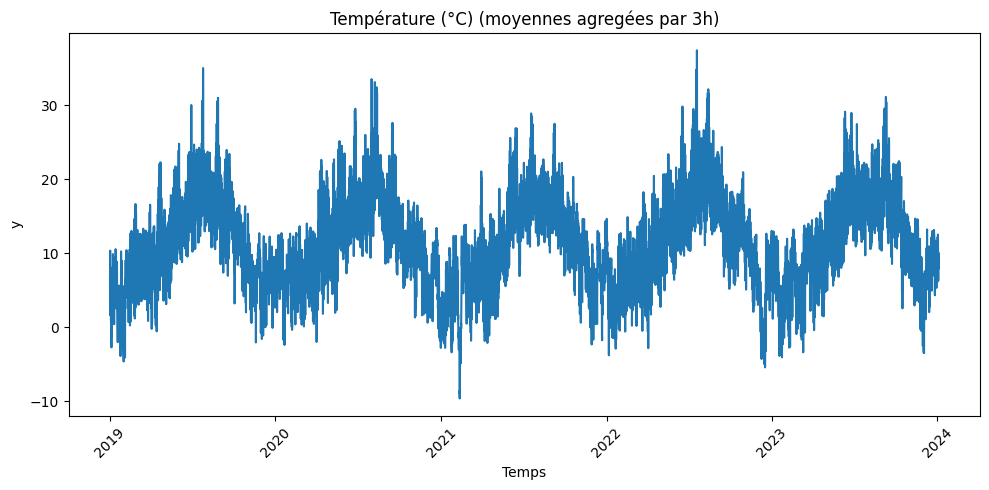

In [ ]:
plot_series(df_3h, "Température (°C) (moyennes agregées par 3h)", "Temps")


**Premières observations**


* La série temporelle ne présente pas de tendance marquée sur la période analysée.
* Elle affiche une saisonnalité annuelle bien prononcée.
* Le modèle de décomposition révèle une composante additive : l’amplitude de la saisonnalité reste relativement stable au fil du temps (pas d’augmentation ou de diminution progressive de l’amplitude ).


Dans le but d’améliorer notre exploration des données, nous procédons à l’extraction de caractéristiques temporelles (jour, heure, mois) depuis la variable timestamp.

In [ ]:

df_3h_new = df_3h.to_frame()

df_3h_new["hour"] = df_3h_new.index.hour
df_3h_new["day"] = df_3h_new.index.day
df_3h_new["month"] = df_3h_new.index.month
df_3h_new["dayofweek"] = df_3h_new.index.dayofweek
df_3h_new["weekofyear"] = df_3h_new.index.isocalendar().week


jours = {
    0: "lundi", 1: "mardi", 2: "mercredi",
    3: "jeudi", 4: "vendredi", 5: "samedi", 6: "dimanche"
}

mois = {
    1: "janvier", 2: "février", 3: "mars", 4: "avril",
    5: "mai", 6: "juin", 7: "juillet", 8: "août",
    9: "septembre", 10: "octobre", 11: "novembre", 12: "décembre"
}

df_3h_new["day_name"] = df_3h_new.index.dayofweek.map(jours)
df_3h_new["month_name"] = df_3h_new.index.month.map(mois)
df_3h_new.head()

,temperature,hour,day,month,dayofweek,weekofyear,day_name,month_name
timestamp,,,,,,,,
2019-01-01 00:00:00,6.800000,0,1,1,1,1,mardi,janvier
2019-01-01 03:00:00,5.100000,3,1,1,1,1,mardi,janvier
2019-01-01 06:00:00,4.500000,6,1,1,1,1,mardi,janvier
2019-01-01 09:00:00,7.400000,9,1,1,1,1,mardi,janvier
2019-01-01 12:00:00,10.366667,12,1,1,1,1,mardi,janvier


## Analyse de la variation de la température au fil des heures d’une journée

<Axes: xlabel='hour'>

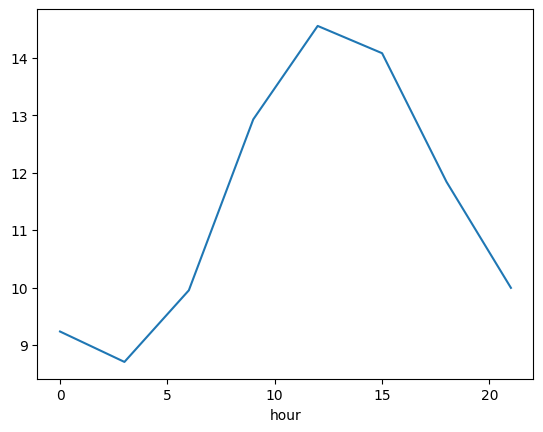

In [ ]:
df_3h_new.groupby("hour")["temperature"].mean().plot(kind="line")

**Commentaire :** De manière générale, la température atteint son maximum aux alentours de 12h, tandis qu’elle est particulièrement basse entre 20h et 5h, correspondant aux heures nocturnes.

## Distribution de la temperature en fonction des jours de la semaine

<Axes: xlabel='day_name'>

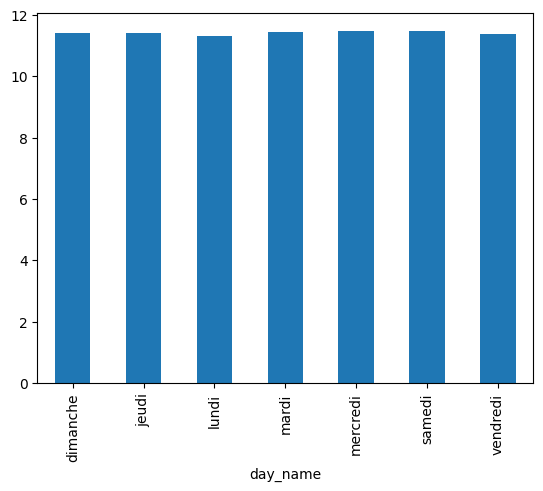

In [ ]:
df_3h_new.groupby("day_name")["temperature"].mean().plot(kind="bar")

**Commentaire :** Les variations de température entre les jours étant faibles, cette caractéristique apporte peu d’information à l’analyse.

### Distribution de la temperature en fonction des mois de l'année

<Axes: xlabel='month_name'>

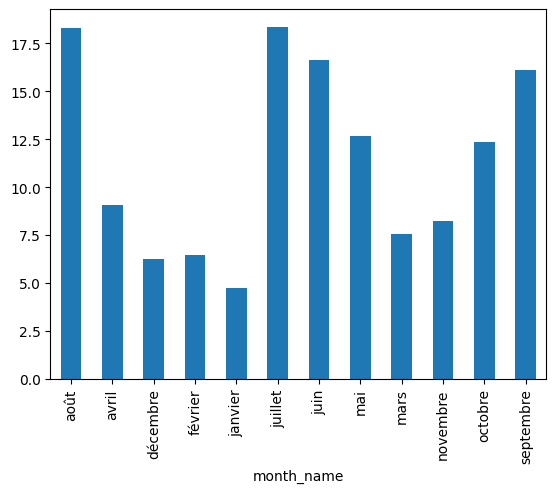

In [ ]:
df_3h_new.groupby("month_name")["temperature"].mean().plot(kind="bar")

**Commentaires :** Les températures moyennes varient significativement selon les mois, avec des valeurs plus élevées en été (juin, juillet, août) et plus faibles en hiver (décembre, janvier, février).

Cette distribution confirme la présence d’une saisonnalité annuelle marquée.

### Visualisation de la température par heure et par mois

<Axes: xlabel='month', ylabel='hour'>

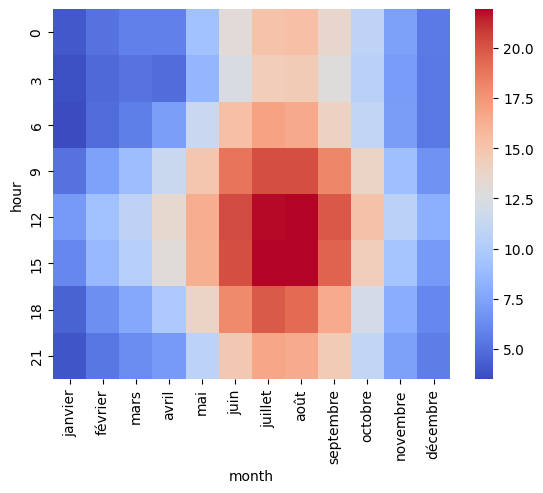

In [ ]:
pivot = df_3h_new.pivot_table(
    values="temperature",
    index="hour",
    columns="month",
    aggfunc="mean"
)

pivot.columns = pivot.columns.map(mois)

sns.heatmap(pivot, cmap="coolwarm")

La heatmap met en évidence une double saisonnalité, avec des températures plus élevées en été (notamment en juillet-août) et aux heures centrales de la journée, tandis que les valeurs les plus basses se concentrent en hiver et durant la nuit.

## Distribution de la variable cible

<Axes: >

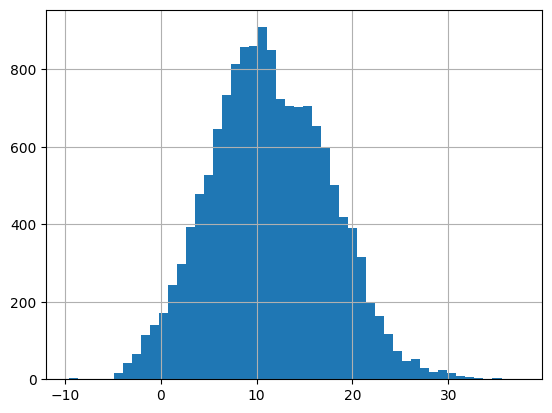

In [ ]:
df_3h_new["temperature"].hist(bins=50)

La distribution présente un léger skew à droite, avec quelques valeurs plus élevées qui étirent la distribution vers les températures les plus fortes.

## Corrélation des features

In [ ]:
corr = df_3h_new.corr(numeric_only=True)
corr


,temperature,hour,day,month,dayofweek,weekofyear
temperature,1.000000,1.538548e-01,3.657334e-02,2.314321e-01,2.887054e-03,2.261088e-01
hour,0.153855,1.000000e+00,4.830693e-17,1.161529e-15,-3.568340e-18,1.139641e-15
day,0.036573,4.830693e-17,1.000000e+00,1.483379e-02,1.245091e-03,7.347050e-02
month,0.231432,1.161529e-15,1.483379e-02,1.000000e+00,2.260281e-03,9.722306e-01
dayofweek,0.002887,-3.568340e-18,1.245091e-03,2.260281e-03,1.000000e+00,1.390700e-03
weekofyear,0.226109,1.139641e-15,7.347050e-02,9.722306e-01,1.390700e-03,1.000000e+00


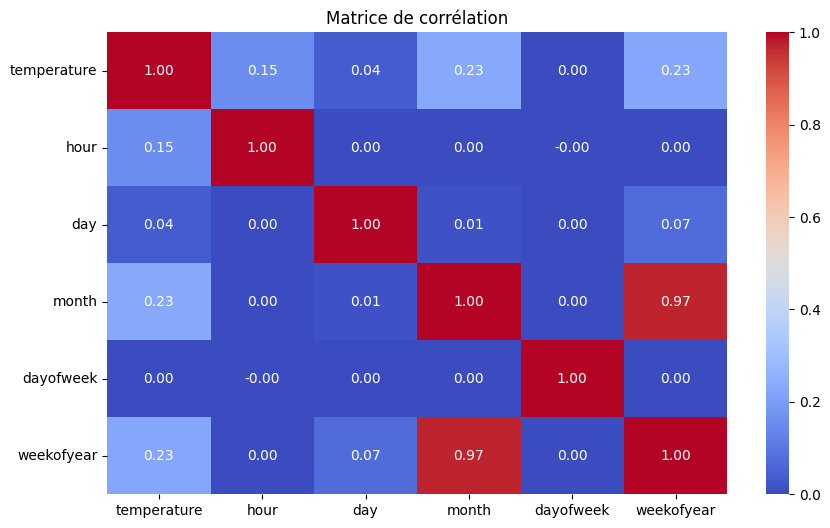

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

La température présente une corrélation modérée avec le mois (0.23) et l’heure (0.15), ce qui met en évidence une saisonnalité annuelle et un cycle journalier.
En revanche, les variables comme le jour et le jour de la semaine ont un impact négligeable sur la température.
Enfin, la forte corrélation entre month et weekofyear (~0.97) indique une redondance, suggérant de ne conserver qu’une seule de ces variables pour la modélisation.
On gardera donc month et hour.

Les variables temporelles hour et month sont cycliques, mais représentées numériquement elles sont linéaires.
La transformation en sin et cos permettra de capturer cette périodicité (23h proche de 0h, décembre proche de janvier) et d’éviter les discontinuités artificielles

## Vérification de la stationnarité de la série

La stationnarité d’une série temporelle est une condition essentielle pour la plupart des méthodes de modélisation et de prévision. En effet, de nombreux modèles, tels que les ARIMA ou les régressions linéaires sur séries temporelles, supposent que les propriétés statistiques de la série (moyenne, variance et autocovariance) restent constantes dans le temps. Vérifier la stationnarité permet d’éviter les régressions fausses, d’assurer la validité des modèles, d’améliorer la précision des prévisions et d’identifier les sources de non-stationnarité (tendances, cycles ou racines unitaires) afin d’appliquer les transformations appropriées (différenciation, etc.)

Pour évaluer visuellement la stationnarité de la série, nous calculons la moyenne mobile et l'écart-type mobile (équivalent à la racine carrée de la variance pour garder l'unité d'origine) sur une fenêtre de 8 observations (équivalente à 1 jour).
Cette fenêtre permet de lisser les fluctuations horaires tout en conservant une bonne sensibilité aux variations de la série.

In [ ]:
rolmean = df_3h.rolling(window=8).mean()
rolstd = df_3h.rolling(window=8).std()


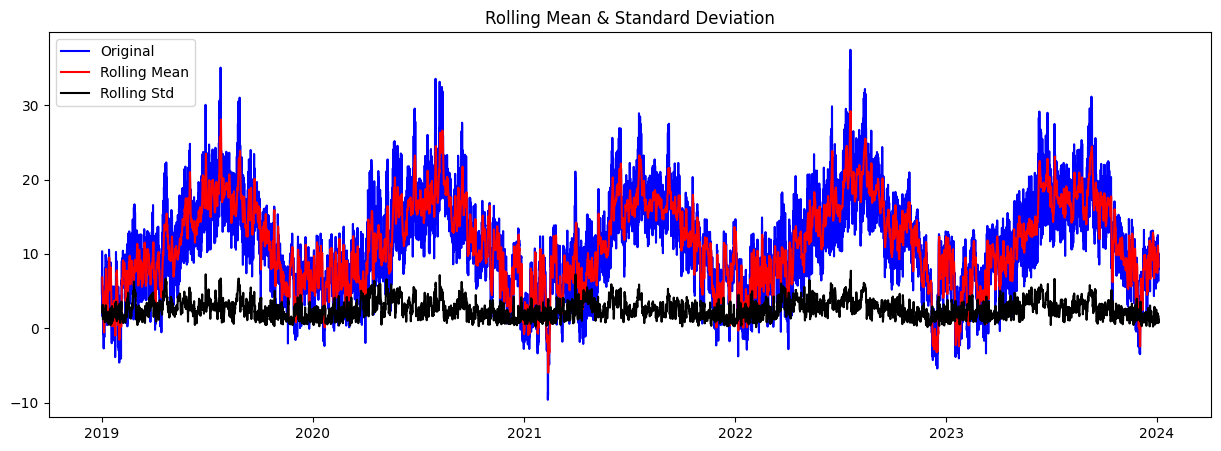

In [ ]:
plt.figure(figsize=(15, 5))
orig = plt.plot(df_3h, color='blue', label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

L’analyse des statistiques mobiles montre que l’écart-type reste globalement stable dans le temps, tandis que la moyenne varie significativement (présence d’une forte saisonnalité annuelle). La série temporelle est donc non stationnaire.

### Test ADF
vérifions la stationnarité avec le test ADF.

Pour qu'une série temporelle soit stationnaire, son test ADF doit présenter :
* une valeur p faible (selon l'hypothèse nulle)
* Les valeurs critiques pour des niveaux de confiance de 1 %, 5 % et 10 % doivent être aussi proches que possible du test statistique

In [ ]:
print('Results of Dickey Fuller Test:')
dftest = adfuller(df_3h, autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value

print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                    -5.292607
p-value                            0.000006
#Lags Used                        42.000000
Number of Observations Used    14589.000000
Critical Value (1%)               -3.430798
Critical Value (5%)               -2.861738
Critical Value (10%)              -2.566875
dtype: float64



**Commentaire :**
Le test ADF rejette l’hypothèse de racine unitaire (p-value ≈ 0.000006).  
Cependant, la série présente une forte saisonnalité annuelle visible graphiquement. Le test ADF standard ne détecte pas ce type de non-stationnarité déterministe.

Effectuons un deuxième test et comparons.

### Test KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

Afin de compléter l’analyse, nous réalisons le test KPSS dont l’hypothèse nulle est que la série est stationnaire.


In [ ]:
def kpss_test(series, **kw):
    statistic, p_value, n_lags, critical_values = kpss(series, **kw)
    print(f'KPSS Statistic: {statistic}')
    print(f'p-value: {p_value}')
    print(f'num lags: {n_lags}')
    print('Critial Values:')
    for key, value in critical_values.items():
        print(f'   {key} : {value}')
    print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

kpss_test(df_3h)


KPSS Statistic: 0.3316285383038262
p-value: 0.1
num lags: 72
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


/tmp/ipykernel_55/3218559401.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, **kw)


Afin de déterminer si la série temporelle de température est stationnaire, nous avons réalisé deux tests complémentaires :

- **Test ADF (Augmented Dickey-Fuller)**  
  - Test Statistic = -5.2926  
  - p-value = 0.000006  
 L’hypothèse nulle de présence d’une racine unitaire est fortement rejetée.

- **Test KPSS**  
  - KPSS Statistic = 0.3316  
  - p-value = 0.1
  L’hypothèse nulle de stationnarité n’est pas rejetée au seuil de 5 %.

**Conclusion**  
Les deux tests concordent pour indiquer que la série est stationnaire. Il n’existe pas de racine unitaire et la variance reste globalement stable dans le temps.

Cependant, cette stationnarité statistique doit être nuancée :  
La série présente une forte saisonnalité annuelle évidente sur les graphiques. Les tests ADF et KPSS standards ne détectent pas toujours ce type de non-stationnarité déterministe liée à la saisonnalité.


La série brute est donc non stationnaire d’un point de vue statistique, mais elle reste fortement saisonnière.  



À ce stade, nous avons deux options :

* Modéliser la série différenciée selon les saisons, puis inversez la différenciation après avoir effectué les prédictions.

* Reproduire directement la série originale.

Alors que l'ARIMA  nécessite une série temporelle non stationnaire et non saisonnière, ces propriétés ne sont pas nécessaires pour la plupart des modèles ML.



## Decomposition de la série

In [ ]:
result = seasonal_decompose(df_3h_new['temperature'], model="additive", period=12)

observed = result.observed
trend = result.trend
seasonal = result.seasonal
residual = result.resid

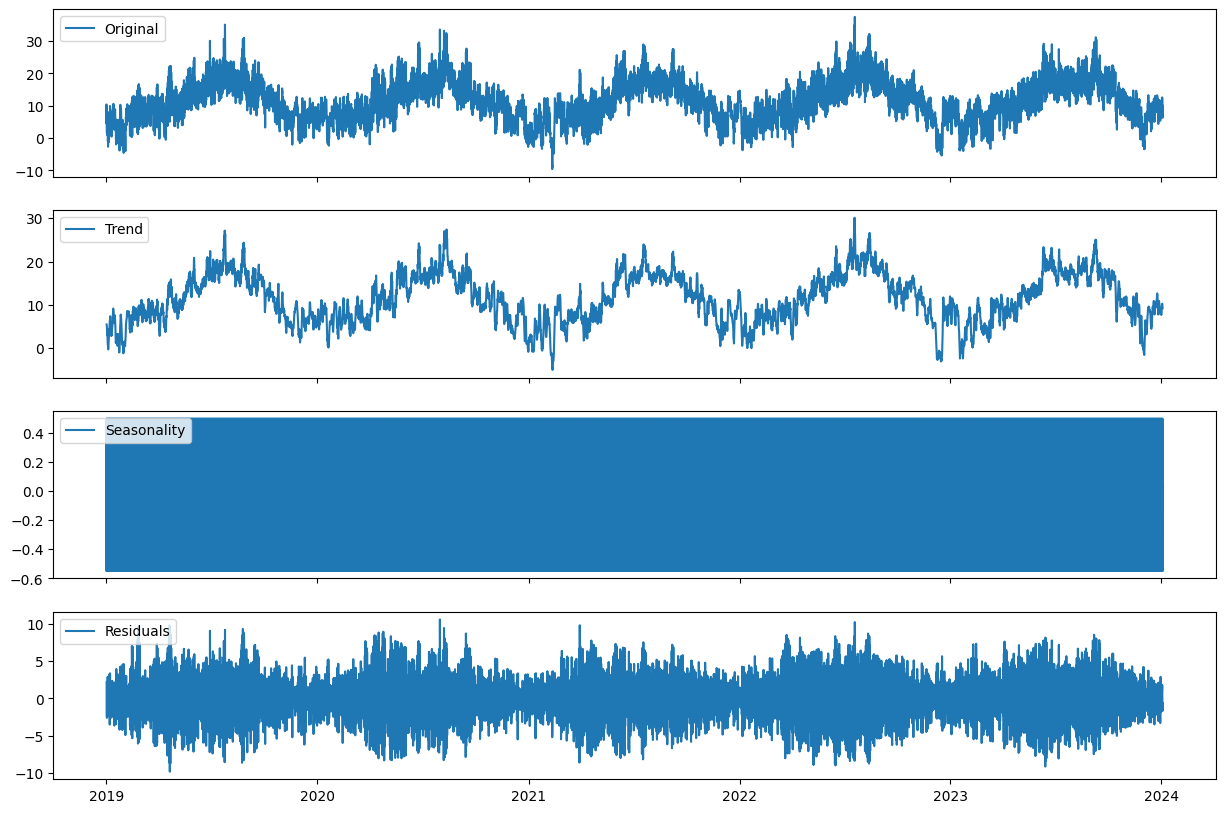

In [ ]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot( observed, label='Original')
axes[0].legend(loc='upper left')

axes[1].plot( trend, label='Trend')
axes[1].legend(loc='upper left')

axes[2].plot( seasonal, label='Seasonality')
axes[2].legend(loc='upper left')

axes[3].plot( residual, label='Residuals')
axes[3].legend(loc='upper left')

La composante saisonnière apparaît très compacte à cette échelle, ce qui rend difficile l’observation des variations ; nous allons donc nous concentrer sur une plage plus restreinte afin de mieux visualiser le pattern saisonnier.

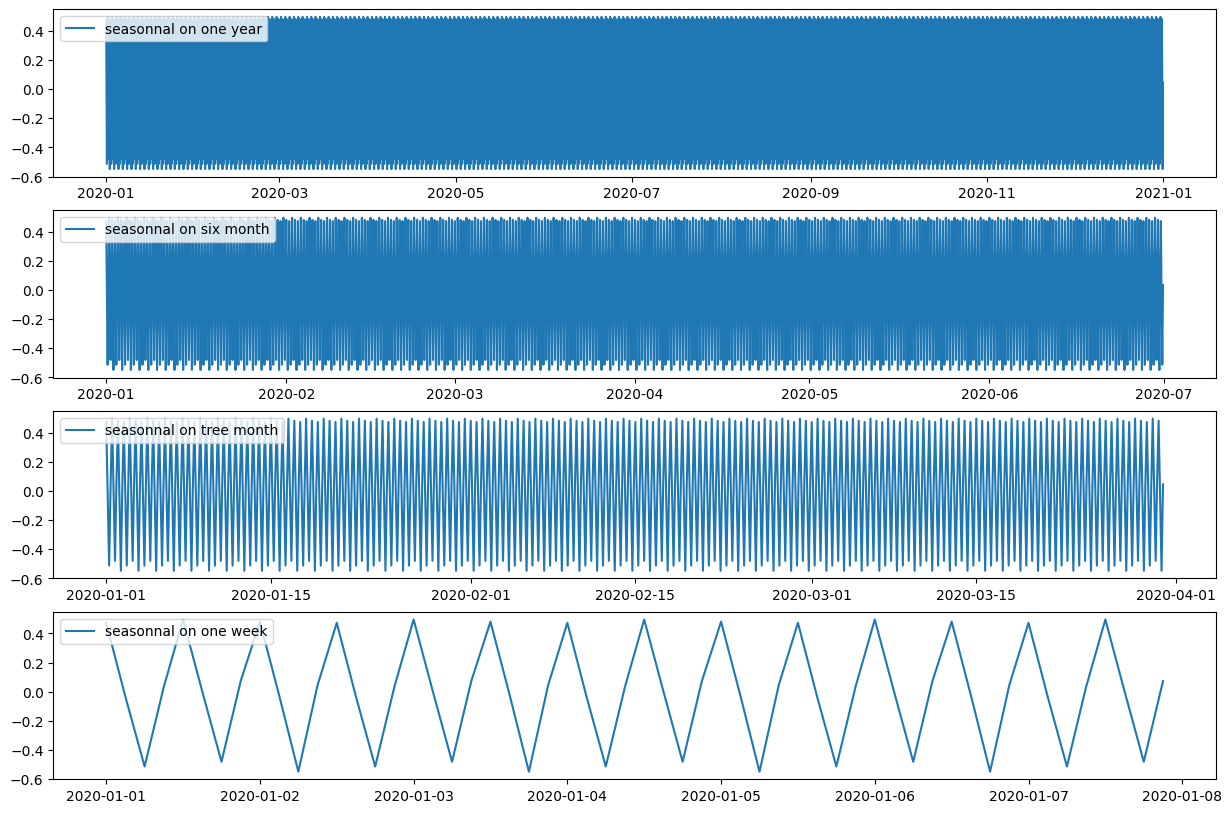

In [ ]:
fig, axes = plt.subplots(4, 1, sharey=True, sharex=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot( seasonal.loc["2020-01-01":"2020-12-31"], label='seasonnal on one year')
axes[0].legend(loc='upper left')

axes[1].plot( seasonal.loc["2020-01-01":"2020-06-30"], label='seasonnal on six month')
axes[1].legend(loc='upper left')

axes[2].plot( seasonal.loc["2020-01-01":"2020-03-30"], label='seasonnal on tree month')
axes[2].legend(loc='upper left')

axes[3].plot( seasonal.loc["2020-01-01":"2020-01-07"], label='seasonnal on one week')
axes[3].legend(loc='upper left')

L’observation de la composante saisonnière sur une semaine met en évidence deux pics par jour, suggérant une saisonnalité intra-journalière d’environ une demi-journée.

## AutoCorrelation

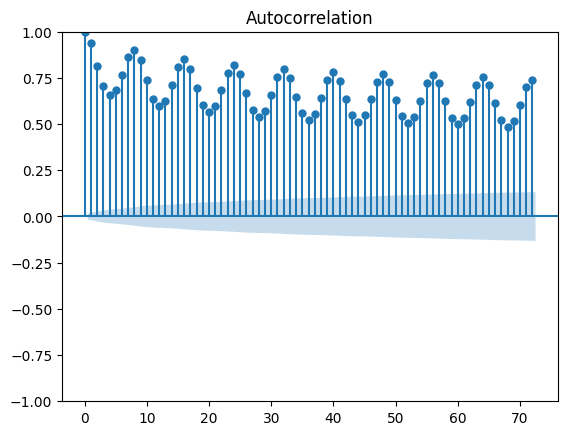

In [ ]:
fig = plot_acf(df_3h_new['temperature'], lags=72, alpha=0.05)

L'ACF montre une autocorrélation très forte et persistante sur tous les lags. On observe également un motif oscillatoire régulier avec des creux tous les 8 lags.

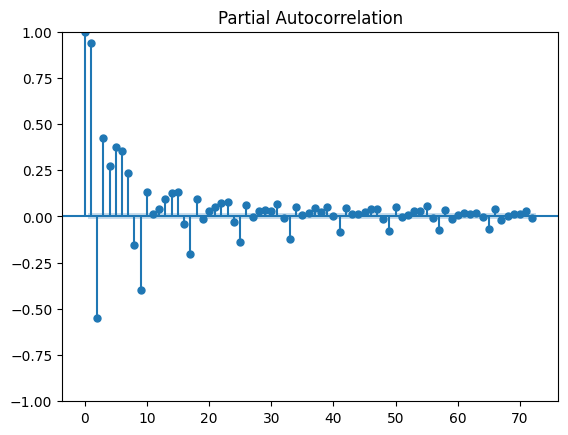

In [ ]:
fig = plot_pacf(df_3h, lags=72, alpha=0.05)

La PACF chute rapidement après les premiers lags (surtout lag 1 et 2) puis devient quasi nulle, suggérant un processus autorégressif d'ordre faible (AR). Les quelques pics significatifs visibles vers les lags 12-13 confirment la présence de la composante saisonnière déjà identifiée.

# Train - Test Split

Nous gardons un année de données pour les tests.

In [ ]:
test_size = 365 * 8  # 1 an

train = df_3h_new.iloc[:-test_size]
test = df_3h_new.iloc[-test_size:]

print(len(train), "points train")
print(len(test), "points test")

11712 points train
2920 points test


# Protocole d'évaluation

Plusieurs métriques existent pour évaluer les modèles de prévision de séries temporelles, en voici quelques unes :

* MAPE (Mean Absolute Percentage Error) : exprime l'erreur en pourcentage, mais devient instable voire indéfini lorsque les valeurs réelles sont proches ou égales à zéro.
* SMAPE (Symmetric MAPE) : corrige partiellement ce problème mais reste difficile à interpréter intuitivement.
* MSE (Mean Squared Error) : pénalise fortement les grandes erreurs mais son unité est le carré de celle de la variable, ce qui nuit à la lisibilité.

Nous avons retenu le MAE et le RMSE pour leur complémentarité : le MAE donne une lecture directe de l'erreur moyenne dans l'unité de la variable, tandis que le RMSE, en élevant les écarts au carré, pénalise davantage les grandes erreurs. Comparer les deux permet de détecter la présence d'erreurs ponctuelles importantes : un RMSE nettement supérieur au MAE signale des pics d'erreur à investiguer. Ces deux métriques restent par ailleurs stables quelle que soit l'amplitude des valeurs, ce qui les rend adaptées à notre série.

# Baseline

Avant d'explorer des modèles plus complexes, il est utile d'établir des baselines simples servant de référence de performance. Trois approches ont été retenues : la moyenne globale, la méthode naïve (recopier la valeur en t-1) et la moyenne mobile. Tout modèle performant devra surpasser ces baselines pour être considéré comme apportant une réelle valeur prédictive.

In [ ]:
results = []

Nous choisossons aléatoirement un horizon de 21 jours et nous observons.

In [ ]:
horizon = 168   # 21 jours


series = df_3h_new["temperature"]

train = series.iloc[:-horizon]
test  = series.iloc[-horizon:]

train_len = len(train)

baseline_results = baseline_forecast(
    series,
    train_len=train_len,
    horizon=horizon,
    window=1,
    ma_window=8
)

results.extend([
    {
    "Modèle":  "baseline_mean",
    "MAE": round(baseline_results['mae_mean'],2),
    "RMSE": round(baseline_results['rmse_mean'],2)
    },
    {
    "Modèle":  "baseline_naive",
    "MAE": round(baseline_results['mae_naive'],2),
    "RMSE": round(baseline_results['rmse_naive'],2)
    },
    {
    "Modèle":  "baseline_ma",
    "MAE": round(baseline_results['mae_ma'],2),
    "RMSE": round(baseline_results['rmse_ma'],2)
    }])

print("MAE mean      :", baseline_results["mae_mean"])
print("MAE naive     :", baseline_results["mae_naive"])
print("MAE moving avg:", baseline_results["mae_ma"])


MAE mean      : 2.6305979001005193
MAE naive     : 0.8916666666666666
MAE moving avg: 1.7204365079365078


**Commentaire :** Sans surprise, la méthode naïve obtient le meilleur score (MAE ≈ 0.89), ce qui est cohérent avec une série fortement autocorrélée où la valeur précédente est déjà un bon prédicteur. La moyenne mobile (MAE ≈ 1.72) se situe en intermédiaire, tandis que la moyenne globale (MAE ≈ 2.63) est la moins performante car elle ignore complètement la structure temporelle de la série.

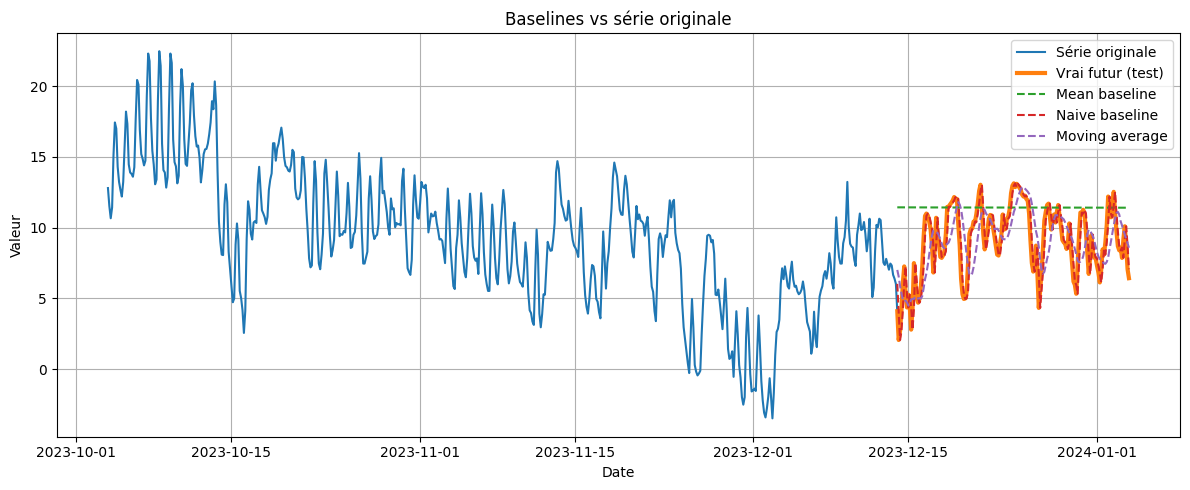

In [ ]:
forecasts = {
    "Mean baseline": baseline_results["mean_pred"],
    "Naive baseline": baseline_results["naive_pred"],
    "Moving average": baseline_results["ma_pred"]
}

plot_baselines(series, test, forecasts)

On constate visuellement que la baseline naive est celle qui se rapproche le plus des fluctuations du vrai futur

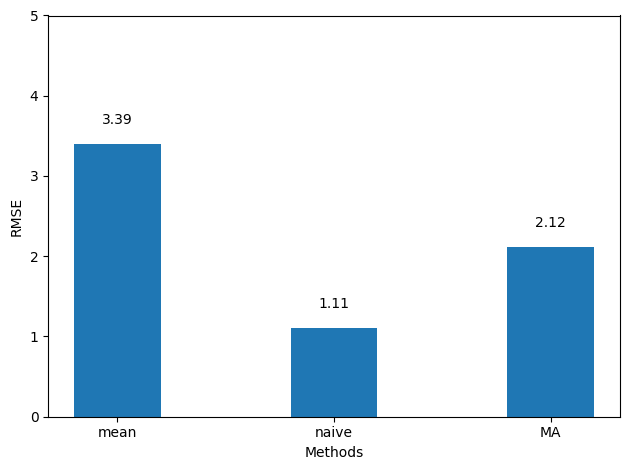

In [ ]:
fig, ax = plt.subplots()

x = ['mean', 'naive', 'MA']
y = [baseline_results["rmse_mean"], baseline_results["rmse_naive"], baseline_results["rmse_ma"]]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('RMSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

Le RMSE confirme les conclusions du MAE : la méthode naïve domine largement (RMSE = 1.11), suivie de la moyenne mobile (2.12) et de la moyenne globale (3.39). L'écart important entre la naïve et les deux autres souligne à quel point la valeur précédente est suffisante pour prédire la suivante.

In [ ]:
SEED = 42

# Expérimentation de modèles de deep learning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

L'heure et le mois sont des variables cycliques : un encodage numérique brut créerait un saut artificiel entre 23h et 0h, ou entre décembre et janvier. La projection sur un cercle trigonométrique via les composantes sin et cos préserve cette continuité, permettant au modèle de percevoir correctement la proximité entre des instants pourtant éloignés numériquement.

In [ ]:
df_3h_new['hour_sin'] = np.sin(2 * np.pi * df_3h_new['hour'] / 24)
df_3h_new['hour_cos'] = np.cos(2 * np.pi * df_3h_new['hour'] / 24)

df_3h_new['month_sin'] = np.sin(2 * np.pi * df_3h_new['month'] / 12)
df_3h_new['month_cos'] = np.cos(2 * np.pi * df_3h_new['month'] / 12)
features = ["temperature", "hour_sin", "hour_cos", "month_sin", "month_cos"]
data = df_3h_new[features].copy()

In [ ]:
data.head()

,temperature,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,
2019-01-01 00:00:00,6.800000,0.000000e+00,1.000000e+00,0.5,0.866025
2019-01-01 03:00:00,5.100000,7.071068e-01,7.071068e-01,0.5,0.866025
2019-01-01 06:00:00,4.500000,1.000000e+00,6.123234e-17,0.5,0.866025
2019-01-01 09:00:00,7.400000,7.071068e-01,-7.071068e-01,0.5,0.866025
2019-01-01 12:00:00,10.366667,1.224647e-16,-1.000000e+00,0.5,0.866025


In [ ]:
scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

On transforme la série temporelle en séquences afin de l’adapter aux modèles comme LSTM ou TCN qui apprennent à partir d’un historique. Concrètement, au lieu de prédire la température à partir d’un seul instant, on utilise une fenêtre glissante de lookback=8 observations (soit 24 heures avec des données toutes les 3h) comme entrée, et on associe à chaque séquence la température du pas de temps suivant (t+1) comme cible. Cela permet au modèle d’apprendre les dépendances temporelles (cycles jour/nuit) et de formuler la prévision comme un problème supervisé.

In [ ]:

lookback = 8

X_train_seq, y_train_seq = create_sequences(scaled_train, lookback)
X_test_seq, y_test_seq = create_sequences(scaled_test, lookback)

print(X_train_seq.shape, y_train_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(11704, 8, 5) (11704,)
(2912, 8, 5) (2912,)


# LSTM


Comme premier modèle deep Learning nous allons utiliser réseaux LSTM (Long Short-Term Memory), un type de réseaux de neurones récurrents (RNN). Ces LSTM sont particulièrement intéressants car ils peuvent mémoriser des informations sur des séquences de données, ce qui s'avère très utile pour les séries temporelles. Les approches RNN plus traditionnelles peinent à se souvenir du passé en raison du fonctionnement des gradients lors de la rétropropagation (problème de disparition du gradient), ce qui les rend plus sujettes à l'oubli.

Le réseau LSTM (Long Short-Term Memory) est un réseau neuronal récurrent entraîné à l'aide de la rétropropagation temporelle qui surmonte le problème de la disparition du gradient.


Le modèle est construit de manière simple, avec une couche LSTM de 64 unités en entrée, suivie d’une couche de dropout pour limiter le surapprentissage, puis d’une couche de sortie à un neurone, adaptée à la prédiction d’une valeur unique.

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential()

    model.add(LSTM(64, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

Un premier entraînement est réalisé en utilisant une validation croisée de type TimeSeriesSplit sur l’ensemble d’entraînement. Contrairement aux méthodes classiques, cette approche respecte l’ordre chronologique des données, évitant ainsi toute fuite d’information entre le passé et le futur.

L’utilisation de TimeSeriesSplit permet d’entraîner et d’évaluer le modèle sur plusieurs découpages temporels successifs, ce qui fournit une meilleure estimation des performances tout en restant cohérent avec la nature séquentielle des séries temporelles. Dans ce contexte, un ensemble de validation distinct n’est pas nécessaire.

In [ ]:
mae_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq)):

    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq[train_idx], X_train_seq[val_idx]
    y_tr, y_val = y_train_seq[train_idx], y_train_seq[val_idx]

    model = build_lstm_model((X_tr.shape[1], X_tr.shape[2]))

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)

    print("MAE:", mae)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print("\nMAE moyen:", np.mean(mae_scores))
print("\nRMSE moyen:", np.mean(rmse_scores))


===== Fold 1 =====


I0000 00:00:1774443002.868999      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774443002.874779      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1774443005.866368     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.03531517732514164

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.02580801922015529

===== Fold 3 =====


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.02079991200448391

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.019897125003159315

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.02270811238869382

MAE moyen: 0.024905669188326793

RMSE moyen: 0.03173848504882428


Le modèle final est ensuite entraîné sur l’ensemble des données d’entraînement en utilisant les paramètres optimaux identifiés lors de la validation croisée temporelle, afin de maximiser ses performances avant l’évaluation finale.

In [ ]:
model_lstm = build_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0166 - mae: 0.0906
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032 - mae: 0.0448
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0028 - mae: 0.0413
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - mae: 0.0387
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - mae: 0.0366
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0018 - mae: 0.0337
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - mae: 0.0312
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0014 - mae: 0.0295
Epoch 9/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013 - mae: 0.0279
Epoch 10/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0011 - mae: 0.0265
Epoch 11/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010 - mae: 0.0250
Epoch 12/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.5552e-04 - mae: 0.0240
Epoch 13/20
366/366 ━━━━━━━━━━━━

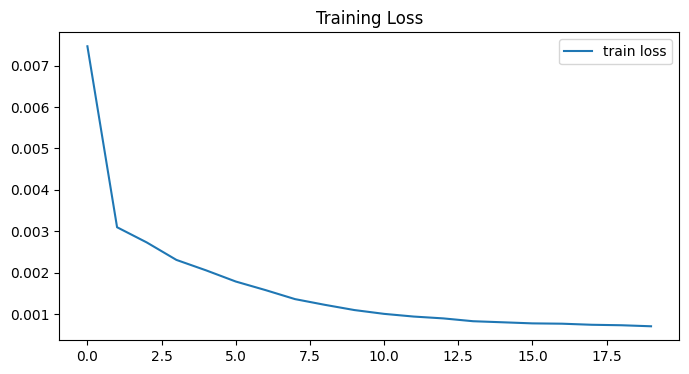

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history_lstm.history["loss"], label="train loss")
plt.title("Training Loss")
plt.legend()

plt.show()

La fonction de perte diminue rapidement au début de l’entraînement puis se stabilise progressivement, ce qui indique que le modèle converge correctement.

Une transformation inverse est appliquée afin de ramener les données à leur échelle d’origine, puis les métriques d’erreur sont calculées pour évaluer les performances du modèle.

In [ ]:
preds_lstm = model_lstm.predict(X_test_seq)
reference = scaled_test[-1]
y_real = inverse_transform_safe(
    y_test_seq,
    scaler,
    reference
)

preds_lstm_real = inverse_transform_safe(
    preds_lstm,
    scaler,
    reference
)

mae_lstm_one_step = mean_absolute_error(y_real, preds_lstm_real)
rmse_lstm_one_step = root_mean_squared_error(y_real, preds_lstm_real)

print("Test MAE du LSTM à une sortie:", round(mae_lstm_one_step,2))
print("Test RMSE du LSTM à une sortie:", round(rmse_lstm_one_step,2))

results.append({
    "Modèle":  "LSTM 1 out",
    "MAE": round(mae_lstm_one_step,2),
    "RMSE": round(rmse_lstm_one_step,2)
})

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test MAE du LSTM à une sortie: 0.81
Test RMSE du LSTM à une sortie: 1.05


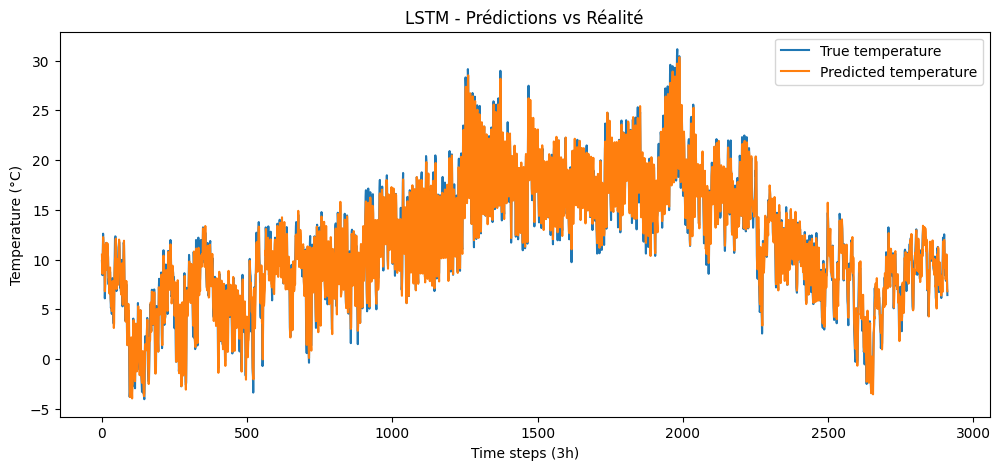

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(y_real, label="True temperature")
plt.plot(preds_lstm_real, label="Predicted temperature")

plt.title("LSTM - Prédictions vs Réalité")
plt.xlabel("Time steps (3h)")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

**Commentaire :** Le LSTM à une sortie obtient un MAE de 0.81 et un RMSE de 1.05, ce qui constitue une amélioration par rapport à la baseline naïve (MAE = 0.89, RMSE = 1.11). L'écart faible entre MAE et RMSE indique que le modèle ne souffre pas d'erreurs ponctuelles importantes. Ces résultats sont encourageants mais restent modestes car le modèle surpasse la baseline sans la dépasser franchement.

Sur le graphique on constate que le modèle suit globalement bien les patterns. Observons plus en detail :

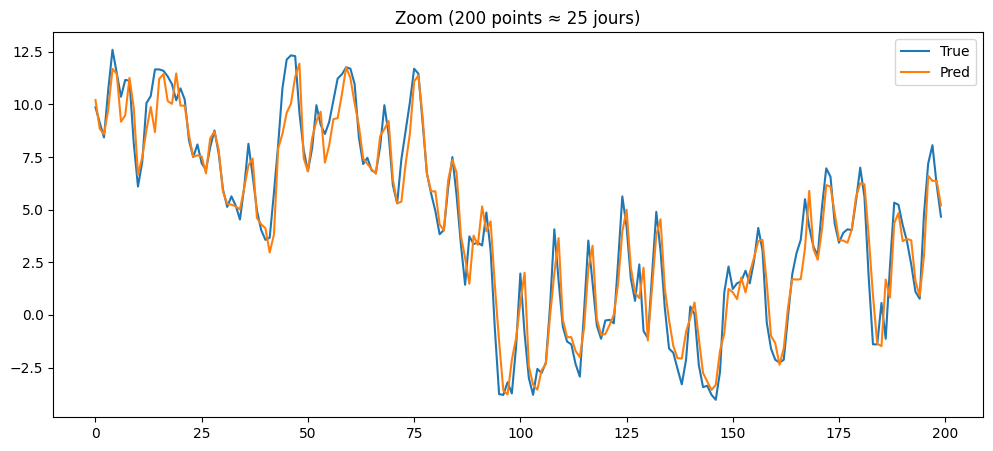

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(y_real[:200], label="True")
plt.plot(preds_lstm_real[:200], label="Pred")

plt.title("Zoom (200 points ≈ 25 jours)")
plt.legend()

plt.show()

Le décalage entre les prédictions et les valeurs réelles est plus prononcé pour les valeurs extrêmes (les plus élevées comme les plus faibles).

Notre objectif étant de prédire sur 3 jours (24 points), nous avons le choix entre deux stratégies : la prédiction récursive et la prediction à sorties multiples (24 points pour 3 jours).

L'approche récursive consiste à réutiliser les prédictions précédentes comme entrées pour les pas suivants, ce qui entraîne une accumulation des erreurs sur un horizon de 3 jours — chaque prédiction erronée dégrade la suivante. Elle est également coûteuse en calcul, car le modèle doit être appelé autant de fois qu'il y a de pas à prédire.

L'approche multi-output prédit directement les 24 pas de temps en une seule fois, évitant ce phénomène de propagation d'erreur. Ce choix est d'autant plus justifié ici que notre horizon de 3 jours est relativement long, rendant l'accumulation d'erreurs de l'approche récursive particulièrement problématique.

## Multi-output LSTM sur 3 jours

On crée des sequences speciales avec horizon de 24 pour les 24 points à prédire correspondant à 3 jours.

In [ ]:


lookback = 8
horizon = 24

X_train_seq_multi, y_train_seq_multi = create_sequences_multistep(scaled_train, lookback, horizon)
X_test_seq_multi, y_test_seq_multi = create_sequences_multistep(scaled_test, lookback, horizon)

print(X_train_seq.shape, y_train_seq.shape)

(11704, 8, 5) (11704,)


In [ ]:
def build_model_lstm_multi(input_shape, horizon):
    model = Sequential()

    model.add(LSTM(64, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(Dense(horizon))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
tscv_multi = TimeSeriesSplit(n_splits=5)

mae_scores  = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv_multi.split(X_train_seq_multi)):
    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
    y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

    model = build_model_lstm_multi((X_tr.shape[1], X_tr.shape[2]), horizon)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val, verbose=0)
    mae   = mean_absolute_error(y_val, preds)
    rmse  = root_mean_squared_error(y_val, preds)

    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print(f"\nMAE moyen  : {np.mean(mae_scores):.4f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.4f}")


===== Fold 1 =====


I0000 00:00:1774473289.424736      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774473289.427972      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1774473293.374710     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


MAE: 0.0481 | RMSE: 0.0609

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0483 | RMSE: 0.0612

===== Fold 3 =====


...

MAE: 0.0467 | RMSE: 0.0600

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0471 | RMSE: 0.0591

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0453 | RMSE: 0.0582

MAE moyen  : 0.0471
RMSE moyen : 0.0599


**Commentaire :**
Les résultats de la cross-validation sur 5 splits sont très stables, avec un MAE moyen de 0.047 et un RMSE moyen de 0.060. La faible variance entre les folds (MAE entre 0.045 et 0.048) indique que le modèle généralise bien et n'est pas sensible à la période choisie pour l'entraînement.

À noter que ces métriques sont calculées sur les données normalisées, elles ne sont donc pas directement comparables aux résultats des baselines exprimés dans l'unité d'origine.

In [ ]:
model_lstm_multi = build_model_lstm_multi((X_train_seq_multi.shape[1], X_train_seq_multi.shape[2]), horizon)

history_lstm_multi = model_lstm_multi.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0448 - mae: 0.1510
Epoch 2/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0667
Epoch 3/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0.0597
Epoch 4/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0051 - mae: 0.0561
Epoch 5/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - mae: 0.0540
Epoch 6/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - mae: 0.0524
Epoch 7/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042 - mae: 0.0512
Epoch 8/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041 - mae: 0.0504
Epoch 9/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040 - mae: 0.0496
Epoch 10/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - mae: 0.0490
Epoch 11/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mae: 0.0485
Epoch 12/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mae: 0.0484
Epoch 13/20
365/365 ━━━━━━━━━━━━━━━━

In [ ]:
preds_lstm_multi = model_lstm_multi.predict(X_test_seq_multi)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:


preds_lstm_multi_real = inverse_transform_multi(preds_lstm_multi, scaler, scaled_train.shape[1])
y_real_multi = inverse_transform_multi(y_test_seq_multi, scaler, scaled_train.shape[1])


mae_lstm_multi = mean_absolute_error(y_real_multi, preds_lstm_multi_real)
rmse_lstm_multi = root_mean_squared_error(y_real_multi, preds_lstm_multi_real)

print("MAE LSTM multi output:", round(mae_lstm_multi,2))
print("RMSE LSTM multi output:", round(rmse_lstm_multi,2))

results.append({
    "Modèle":  "LSTM multi output",
    "MAE": round(mae_lstm_multi,2),
    "RMSE": round(rmse_lstm_multi,2)
})


MAE LSTM multi output: 2.08
RMSE LSTM multi output: 2.65


In [ ]:
df_results = pd.DataFrame(results).set_index("Modèle")
df_results

,MAE,RMSE
Modèle,,
baseline_mean,2.63,3.39
baseline_naive,0.89,1.11
baseline_ma,1.72,2.12
LSTM multi output,2.08,2.65
LSTM multi output,2.08,2.65


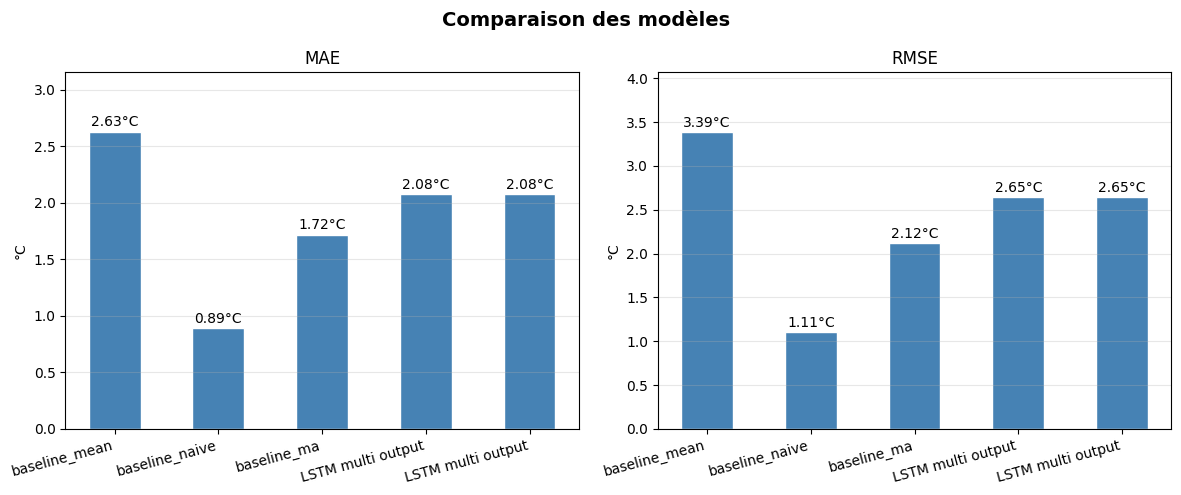

In [ ]:
plot_model_comparison(results)

**Commentaire :**
Les résultats montrent que le LSTM 1 sortie obtient les meilleures performances avec une MAE de 0.84°C et un RMSE de 1.08°C, talonnant de près la baseline naive (0.89°C / 1.11°C). Cela s'explique par la forte auto-corrélation à court terme de la série temporelle de température : la valeur à t+1 est naturellement très proche de t, ce que le modèle a appris mais sans apporter de valeur ajoutée significative par rapport à une simple persistence.

Le LSTM multi output (2.09°C / 2.67°C) est plus décevant — il prédit 24 pas simultanément avec un contexte de seulement lookback=8 (24 points), ce qui est insuffisant pour capturer les patterns sur 72h. Ces résultats suggèrent comme piste d'amélioration l'augmentation du lookback du modèle multi output.

#  TCN   

Le TCN est une architecture de réseau de neurones convolutif adapté aux séries temporelles. Contrairement aux RNN/LSTM, il traite la séquence en parallèle via des convolutions causales dilatées, ce qui le rend plus rapide à entraîner tout en capturant des dépendances à long terme grâce à l'effet des dilatations successives.

**Architecture retenue**

Le modèle est composé d'une couche TCN suivie d'une couche Dense de sortie :

- **nb_filters=64** : 64 filtres convolutifs pour capturer des représentations suffisamment riches
- **kernel_size=3** : fenêtre de convolution de taille 3
- **dilations=[1, 2, 4, 8]** : dilatations exponentielles permettant de couvrir un champ réceptif de 1 + (3-1) × (1+2+4+8) = 31 pas de temps sans augmenter le nombre de paramètres
- **dropout_rate=0.2** : régularisation pour limiter le surapprentissage
- **Dense(1)** : sortie scalaire pour la prédiction multi-output
- **Optimiseur Adam** avec une loss MSE

## 1 step simple forecast

In [ ]:
def build_tcn(input_shape):
    model = Sequential()

    model.add(TCN(
        input_shape=input_shape,
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.2
    ))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:

mae_scores = []
rsme_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq)):

    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq[train_idx], X_train_seq[val_idx]
    y_tr, y_val = y_train_seq[train_idx], y_train_seq[val_idx]

    model = build_tcn((X_tr.shape[1], X_tr.shape[2]))

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)
    print("MAE:", mae)
    mae_scores.append(mae)
    rsme_scores.append(rmse)
print("\nMAE moyen:", np.mean(mae_scores))
print("\nRMSE moyen:", np.mean(rsme_scores))


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)
I0000 00:00:1774443528.448051     142 service.cc:152] XLA service 0x7a5b040ba750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774443528.448089     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774443528.448095     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774443535.381100     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
MAE: 0.04716903024179021

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
MAE: 0.02858783055945986

===== Fold 3 =====


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
MAE: 0.026332774756034526

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.02076129154635164

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.02726703463799927

MAE moyen: 0.030023592348327098

RMSE moyen: 0.03796201117459978


**Commentaire :**
Le TCN obtient un MAE moyen de 0.030 et un RMSE moyen de 0.038, soit une nette amélioration par rapport au LSTM (MAE = 0.047, RMSE = 0.060). En revanche, on note une variance plus élevée entre les folds (MAE entre 0.021 et 0.047), le fold 1 étant nettement moins bon que les autres — ce qui suggère que le modèle est plus sensible à la période d'entraînement que le LSTM.

In [ ]:
model_tcn = build_tcn((X_train_seq.shape[1], X_train_seq.shape[2]))

history_tcn_simple = model_tcn.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


366/366 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.3579 - mae: 0.3926
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0139 - mae: 0.0927
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063 - mae: 0.0625
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0038 - mae: 0.0485
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - mae: 0.0408
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - mae: 0.0362
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - mae: 0.0334
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0301
Epoch 9/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0281
Epoch 10/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - mae: 0.0265
Epoch 11/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - mae: 0.0257
Epoch 12/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010 - mae: 0.0250
Epoch 13/20
366/366 ━━━━━━━━━━━━━━

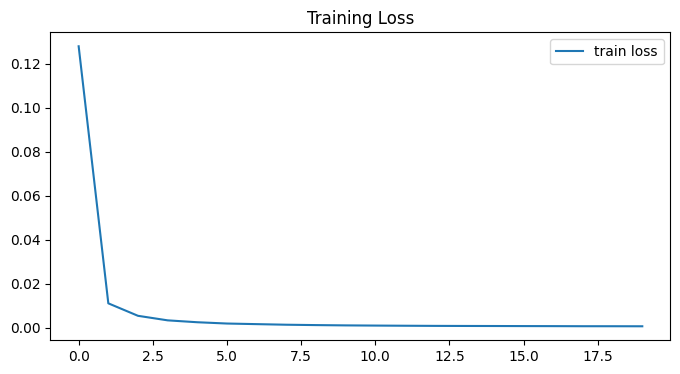

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history_tcn_simple.history["loss"], label="train loss")
plt.title("Training Loss")
plt.legend()

plt.show()

La courbe de loss montre une convergence rapide et stable : la perte chute fortement dès les 2-3 premières époques puis se stabilise proche de zéro, sans oscillations. L'absence de courbe de validation ne permet pas de détecter un éventuel surapprentissage, mais la forme régulière de la courbe est un bon signe.

In [ ]:
preds_tcn_simple = model_tcn.predict(X_test_seq)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
reference = scaled_test[-1]

preds_tcn_real = inverse_transform_safe(
    preds_tcn_simple,
    scaler,
    reference
)

mae_tcn_simple = mean_absolute_error(y_real, preds_tcn_real)
rmse_tcn_simple = root_mean_squared_error(y_real, preds_tcn_real)

print("MAE TCN simple:", mae_tcn_simple)
print("RMSE TCN simple:", rmse_tcn_simple)


results.append({
    "Modèle":  "TCN simple",
    "MAE": round(mae_tcn_simple,2),
    "RMSE": round(rmse_tcn_simple,2)
})

MAE TCN simple: 1.1622541539020488
RMSE TCN simple: 1.4626244685274405


In [ ]:
# results.pop()
df_results = pd.DataFrame(results).set_index("Modèle")
df_results


,MAE,RMSE
Modèle,,
baseline_mean,2.63,3.39
baseline_naive,0.89,1.11
baseline_ma,1.72,2.12
LSTM 1 out,0.81,1.05
LSTM multi output,2.11,2.67
TCN simple,1.16,1.46


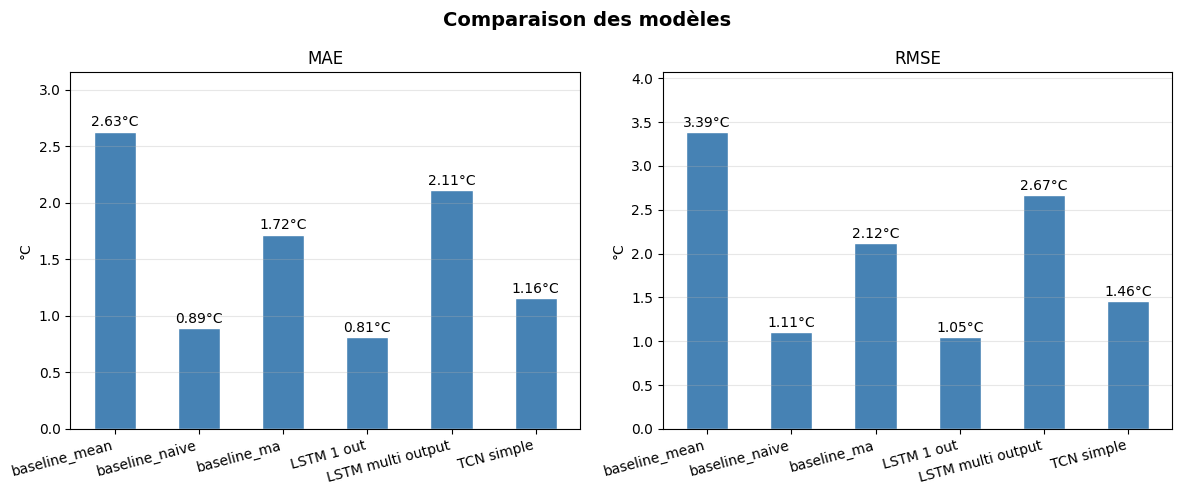

In [ ]:
plot_model_comparison(results)

**Commentaire :**

Le TCN simple affiche des performances légèrement inférieures à la baseline naive, avec un écart de +0.11°C en MAE et +0.16°C en RMSE. Ce résultat suggère que l'architecture utilisée est probablement trop simple pour capturer les dépendances temporelles de la série .
le LSTM reste le meilleur.

## TCN Multioutput forecast 3 jours

In [ ]:
def build_tcn_multistep(input_shape, horizon):
    model = Sequential()

    model.add(TCN(
        input_shape=input_shape,
        nb_filters=64,
        kernel_size=3,
        dilations=[1,2,4,8],
        dropout_rate=0.2
    ))

    model.add(Dense(horizon))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
mae_scores = []
rmse_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq_multi)):

    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
    y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

    model = build_tcn_multistep((X_tr.shape[1], X_tr.shape[2]), horizon)

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)
    print("MAE:", mae)
    print("RMSE:", rmse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print("\nMAE moyen:", np.mean(mae_scores))
print("\nRMSE moyen:", np.mean(rmse_scores))


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.05936560257287976
RMSE: 0.07359423298221025

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.053567197486016765
RMSE: 0.06853045621940977

===== Fold 3 =====


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.045662623563638545
RMSE: 0.05914020388190446

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.04868304174712884
RMSE: 0.06071873700877587

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE: 0.052318877631908844
RMSE: 0.06635214701160101

MAE moyen: 0.05191946860031456

RMSE moyen: 0.06566715542078028


**Commentaire :**

Le TCN multi-output obtient un MAE moyen de 0.052 et un RMSE moyen de 0.066, des résultats moins bons que le TCN une sortie (MAE = 0.030, RMSE = 0.038). La tâche est cependant plus difficile : le modèle doit prédire 72 pas de temps simultanément au lieu d'un seul. En revanche, la variance entre les folds est plus faible et plus homogène, ce qui indique une meilleure stabilité que le TCN une sortie.

In [ ]:
model_tcn_multistep= build_tcn_multistep((X_train_seq_multi.shape[1], X_train_seq_multi.shape[2]), horizon)

model_tcn_multistep.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=20,
    batch_size=32
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.0080 - mae: 0.5040
Epoch 2/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0201 - mae: 0.1110
Epoch 3/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - mae: 0.0834
Epoch 4/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0717
Epoch 5/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0068 - mae: 0.0644
Epoch 6/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - mae: 0.0602
Epoch 7/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054 - mae: 0.0574
Epoch 8/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - mae: 0.0561
Epoch 9/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048 - mae: 0.0543
Epoch 10/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0045 - mae: 0.0528
Epoch 11/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - mae: 0.0521
Epoch 12/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - mae: 0.0512
Epoch 13/20
365/365 ━━━━━━━━━━━━━━━

In [ ]:
preds_tcn_multi = model_tcn_multistep.predict(X_test_seq_multi)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
preds_tcn_multi_real = inverse_transform_multi(preds_tcn_multi, scaler, scaled_train.shape[1])

mae_tcn_multi = mean_absolute_error(y_real_multi, preds_tcn_multi_real)
rmse_tcn_multi = root_mean_squared_error(y_real_multi, preds_tcn_multi_real)

print("MAE TCN multi output:", round(mae_tcn_multi,2))
print("RMSE TCN multi output:", round(rmse_tcn_multi,2))

results.append({
    "Modèle":  "TCN multi output",
    "MAE": round(mae_tcn_multi,2),
    "RMSE": round(rmse_tcn_multi,2)
})


MAE TCN multi output: 2.15
RMSE TCN multi output: 2.75


In [ ]:
# results.pop()
df_results = pd.DataFrame(results).set_index("Modèle")
df_results


,MAE,RMSE
Modèle,,
baseline_mean,2.63,3.39
baseline_naive,0.89,1.11
baseline_ma,1.72,2.12
LSTM 1 out,0.81,1.05
LSTM multi output,2.11,2.67
TCN simple,1.16,1.46
TCN multi output,2.15,2.75


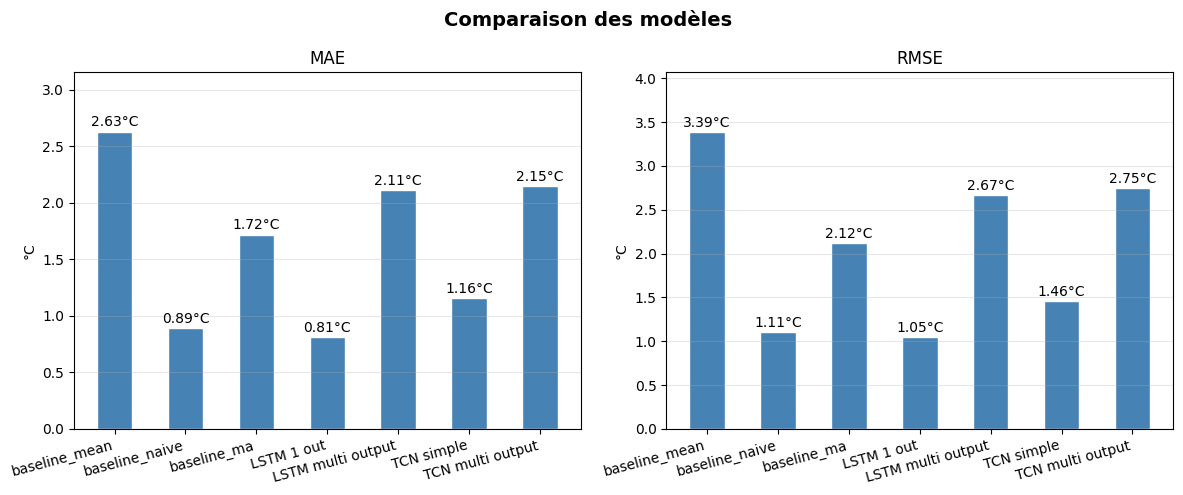

In [ ]:
plot_model_comparison(results)

**Commentaire :**

Pour l'objectif de prédiction sur 3 jours (24 points), les deux modèles pertinents sont le **LSTM multi-output** (MAE = 2.11°C, RMSE = 2.67°C) et le **TCN multi-output** (MAE = 2.15°C, RMSE = 2.75°C), qui affichent des performances très proches. Les deux surpassent largement les baselines moyenne et moyenne mobile, mais restent en retrait par rapport à la baseline naïve — ce qui s'explique par la difficulté intrinsèque de prédire 24 pas de temps simultanément. Avec une erreur moyenne d'environ **2°C sur 3 jours**, ces résultats constituent une base solide, et le LSTM multi-output se dégage légèrement comme le meilleur modèle pour cet objectif.

# Stratégie d'amelioration : Test des deux modèles multi output avec lookback = 24

Le lookback, c'est-à-dire la fenêtre d'historique fournie en entrée au modèle, est un hyperparamètre clé en prévision de séries temporelles. Jusqu'ici, cette valeur n'a pas été optimisée — nous testons ici un lookback de 24 heures, correspondant exactement à une journée complète, afin de vérifier si fournir au modèle un historique aligné sur la saisonnalité journalière améliore les prédictions sur les 3 jours suivants.

In [ ]:
lookback = 24
horizon = 24

X_train_seq_multi, y_train_seq_multi = create_sequences_multistep(scaled_train, lookback, horizon)
X_test_seq_multi, y_test_seq_multi = create_sequences_multistep(scaled_test, lookback, horizon)

print(X_train_seq_multi.shape, y_train_seq_multi.shape)

(11664, 24, 5) (11664, 24)


In [ ]:
results_24 = []

## LSTM

In [ ]:
tscv_multi = TimeSeriesSplit(n_splits=5)

mae_scores  = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv_multi.split(X_train_seq_multi)):
    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
    y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

    model = build_model_lstm_multi((X_tr.shape[1], X_tr.shape[2]), horizon)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val, verbose=0)
    mae   = mean_absolute_error(y_val, preds)
    rmse  = root_mean_squared_error(y_val, preds)

    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print(f"\nMAE moyen  : {np.mean(mae_scores):.4f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.4f}")


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0484 | RMSE: 0.0611

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0485 | RMSE: 0.0612

===== Fold 3 =====


...

MAE: 0.0469 | RMSE: 0.0602

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0476 | RMSE: 0.0595

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0457 | RMSE: 0.0588

MAE moyen  : 0.0474
RMSE moyen : 0.0601


In [ ]:
model_lstm_24 = build_model_lstm_multi((X_train_seq_multi.shape[1], X_train_seq_multi.shape[2]), horizon)

history_lstm_24 = model_lstm_24.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=20,
    batch_size=32
)

Epoch 1/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0405 - mae: 0.1434
Epoch 2/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0072 - mae: 0.0669
Epoch 3/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0058 - mae: 0.0600
Epoch 4/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0051 - mae: 0.0563
Epoch 5/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0048 - mae: 0.0545
Epoch 6/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0044 - mae: 0.0523
Epoch 7/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0043 - mae: 0.0514
Epoch 8/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0041 - mae: 0.0501
Epoch 9/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0040 - mae: 0.0496
Epoch 10/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0039 - mae: 0.0488
Epoch 11/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0038 - mae: 0.0481
Epoch 12/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0038 - mae: 0.0480
Epoch 13/20
365/365 ━━━━━

In [ ]:
preds_lstm_24 = model_lstm_24.predict(X_test_seq_multi)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
preds_lstm_24_real = inverse_transform_multi(preds_lstm_24, scaler, scaled_train.shape[1])
y_real_multi = inverse_transform_multi(y_test_seq_multi, scaler, scaled_train.shape[1])


mae_lstm_24 = mean_absolute_error(y_real_multi, preds_lstm_24_real)
rmse_lstm_24 = root_mean_squared_error(y_real_multi, preds_lstm_24_real)

print("MAE LSTM multi output:", round(mae_lstm_24,2))
print("RMSE LSTM multi output:", round(mae_lstm_24,2))

results_24.append({
    "Modèle":  "LSTM",
    "MAE": round(mae_lstm_24,2),
    "RMSE": round(mae_lstm_24,2)
})


MAE LSTM multi output: 2.09
RMSE LSTM multi output: 2.09


In [ ]:
print(X_test_seq_multi.shape)
print(y_test_seq_multi.shape)

print(preds_lstm_24.min(), preds_lstm_24.max())

print(model_lstm_24.input_shape)

(2872, 24, 5)
(2872, 24)
0.105163425 0.79507047
(None, 24, 5)


## TCN

In [ ]:
mae_scores = []
rmse_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq_multi)):

    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
    y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

    model = build_tcn_multistep((X_tr.shape[1], X_tr.shape[2]), horizon)

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)
    print("MAE:", mae)
    print("RMSE:", rmse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print("\nMAE moyen:", np.mean(mae_scores))
print("\nRMSE moyen:", np.mean(rmse_scores))


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
MAE: 0.07439313303798756
RMSE: 0.09023031596788644

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE: 0.061194705804947735
RMSE: 0.0778423146308314

===== Fold 3 =====


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
MAE: 0.04935647380861955
RMSE: 0.06379274772992395

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
MAE: 0.05120123791276041
RMSE: 0.06320134293338613

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE: 0.05512592908952305
RMSE: 0.0696675466534799

MAE moyen: 0.05825429593076766

RMSE moyen: 0.07294685358310157


In [ ]:
model_tcn_24= build_tcn_multistep((X_train_seq_multi.shape[1], X_train_seq_multi.shape[2]), horizon)

history_tcn_24 = model_tcn_24.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=20,
    batch_size=32
)

Epoch 1/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 1.0782 - mae: 0.5286
Epoch 2/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0229 - mae: 0.1184
Epoch 3/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - mae: 0.0779
Epoch 4/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0075 - mae: 0.0679
Epoch 5/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0068 - mae: 0.0650
Epoch 6/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0064 - mae: 0.0628
Epoch 7/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - mae: 0.0610
Epoch 8/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - mae: 0.0593
Epoch 9/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - mae: 0.0579
Epoch 10/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - mae: 0.0566
Epoch 11/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - mae: 0.0547
Epoch 12/20
365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0048 - mae: 0.0542
Epoch 13/20
365/365 ━━━

In [ ]:
preds_tcn_24 = model_tcn_24.predict(X_test_seq_multi)

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
preds_tcn_24_real = inverse_transform_multi(preds_tcn_24, scaler, scaled_train.shape[1])

mae_tcn_24 = mean_absolute_error(y_real_multi, preds_tcn_24_real)
rmse_tcn_24 = root_mean_squared_error(y_real_multi, preds_tcn_24_real)

print("MAE TCN multi output:", round(mae_tcn_24,2))
print("RMSE TCN multi output:", round(rmse_tcn_24,2))

results_24.append({
    "Modèle":  "TCN",
    "MAE": round(mae_tcn_24,2),
    "RMSE": round(rmse_tcn_24,2)
})


MAE TCN multi output: 2.2
RMSE TCN multi output: 2.81


In [ ]:
print(X_test_seq_multi.shape)
print(X_test_seq_multi.shape)
print(preds_tcn_24.min(), preds_tcn_24.max())

print(model_tcn_24.input_shape)

(2872, 24, 5)
(2872, 24, 5)
0.21420404 0.75141954
(None, 24, 5)


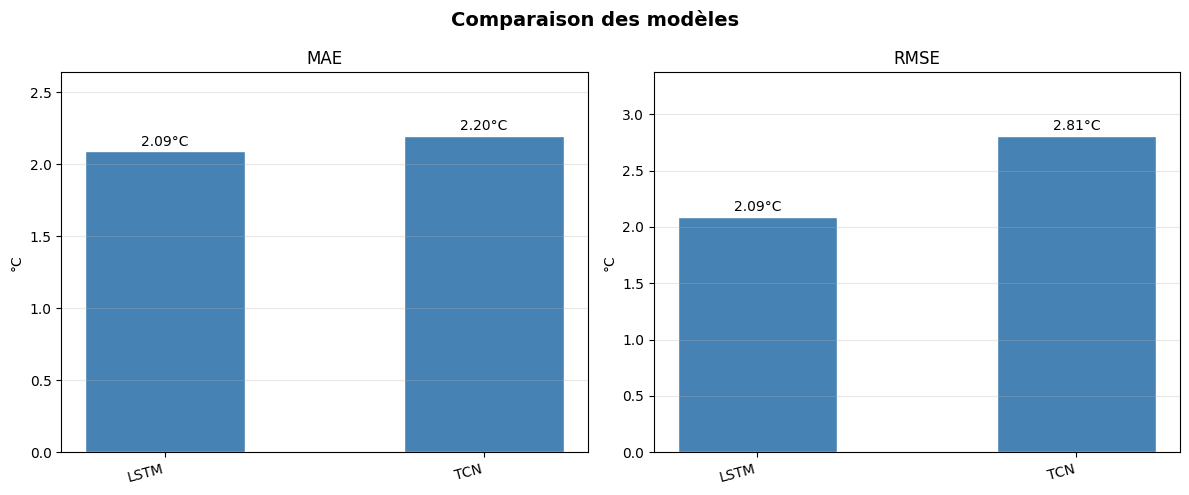

In [ ]:
df_results_24 = pd.DataFrame(results_24).set_index("Modèle")
df_results_24

plot_model_comparison(results_24)

Le passage à un lookback de 24 n'apporte pas d'amélioration significative : le LSTM obtient un MAE de 2.09°C (vs 2.11°C) et le TCN 2.20°C (vs 2.15°C), soit des écarts quasi négligeables. L'hypothèse qu'un historique aligné sur la saisonnalité journalière améliorerait les prédictions ne se confirme pas ici — le lookback initial semble déjà suffisant pour capturer les dépendances temporelles pertinentes.

Neanmoins, Nous conservons le LSTM multi-ouput pour la suite.

# Fine Tuning LSTM multi output


On finetune le modèle LSTM.

Par rapport au modèle initial, plusieurs améliorations ont été apportées :

* Ajout d'une deuxième couche LSTM (128 → 64 unités avec return_sequences=True) : permet d'apprendre des représentations temporelles à plusieurs niveaux d'abstraction
* Augmentation de la capacité : la première couche passe de 64 à 128 unités pour capturer des patterns plus complexes
* Ajout d'une couche Dense(32, relu) : introduit une non-linéarité supplémentaire avant la sortie pour mieux modéliser les relations entre les features extraites et les prédictions


In [ ]:
lookback = 24
horizon = 24


In [ ]:
def build_model_lstm_multi_v2(input_shape, horizon):
    model = Sequential()

    model.add(LSTM(128, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=False))
    # model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))

    model.add(Dense(horizon))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

In [ ]:
tscv_multi = TimeSeriesSplit(n_splits=5)

mae_scores  = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv_multi.split(X_train_seq_multi)):
    print(f"\n===== Fold {fold+1} =====")

    X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
    y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

    model = build_model_lstm_multi_v2((X_tr.shape[1], X_tr.shape[2]), horizon)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val, verbose=0)
    mae   = mean_absolute_error(y_val, preds)
    rmse  = root_mean_squared_error(y_val, preds)

    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print(f"\nMAE moyen  : {np.mean(mae_scores):.4f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.4f}")


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0571 | RMSE: 0.0709

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0496 | RMSE: 0.0633

===== Fold 3 =====


...

MAE: 0.0478 | RMSE: 0.0611

===== Fold 4 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0472 | RMSE: 0.0593

===== Fold 5 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 0.0459 | RMSE: 0.0589

MAE moyen  : 0.0495
RMSE moyen : 0.0627


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True)
]
model_lstm_multi_v2 = build_model_lstm_multi_v2((X_train_seq_multi.shape[1], X_train_seq_multi.shape[2]), horizon)


history_lstm_multi_v2 = model_lstm_multi_v2.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)



Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


365/365 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0401 - mae: 0.1385
Epoch 2/30
 31/365 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0069 - mae: 0.0659

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0058 - mae: 0.0604
Epoch 3/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0045 - mae: 0.0533
Epoch 4/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0043 - mae: 0.0516
Epoch 5/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0040 - mae: 0.0499
Epoch 6/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0039 - mae: 0.0488
Epoch 7/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0040 - mae: 0.0494
Epoch 8/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0038 - mae: 0.0484
Epoch 9/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0039 - mae: 0.0486
Epoch 10/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0038 - mae: 0.0479
Epoch 11/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0037 - mae: 0.0475
Epoch 12/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0037 - mae: 0.0478
Epoch 13/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0036 - mae: 0.0470
Epoch 14/30
365/365 ━━━━━━━━━━━━━━━

In [ ]:
preds_lstm_multi_v2 = model_lstm_multi_v2.predict(X_test_seq_multi)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
preds_lstm_multi_v2_real = inverse_transform_multi(preds_lstm_multi_v2, scaler, scaled_train.shape[1])

mae = mean_absolute_error(y_real_multi, preds_lstm_multi_v2_real)
rmse = root_mean_squared_error(y_real_multi, preds_lstm_multi_v2_real)

print("Test MAE LSTM finetuné:", mae)
print("Test RMSE LSTM finetuné:", rmse)

results_24.append({
    "Modèle":  "LSTM finetune",
    "MAE": round(mae,2),
    "RMSE": round(rmse,2)
})


Test MAE LSTM finetuné: 2.0923833154018645
Test RMSE LSTM finetuné: 2.636963614830751


Le fine-tuning du LSTM n'apporte pas d'amélioration notable : les deux modèles affichent un MAE identique de 2.09°C. En revanche, le RMSE du modèle fine-tuné est nettement plus élevé (2.64°C vs 2.09°C), ce qui révèle une plus grande sensibilité aux erreurs ponctuelles.

Néanmoins nous allons tenter de tester differents paramètres à l'aide de la librairie optuna

In [ ]:
! pip install optuna

In [ ]:
tscv_optuna = TimeSeriesSplit(n_splits=3)

def objective(trial):
    batch_size   = trial.suggest_categorical("batch_size", [32, 64])
    n_units_1    = trial.suggest_int("lstm_units_1", 32, 128, step=32)
    n_units_2    = trial.suggest_int("lstm_units_2", 32, 128, step=32)
    dense_units  = trial.suggest_int("dense_units", 16, 64, step=16)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.4)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    rmse_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv_optuna.split(X_train_seq_multi)):
        X_tr, X_val = X_train_seq_multi[train_idx], X_train_seq_multi[val_idx]
        y_tr, y_val = y_train_seq_multi[train_idx], y_train_seq_multi[val_idx]

        optimizer = Adam(learning_rate=lr)

        model = Sequential([
            Input(shape=(X_tr.shape[1], X_tr.shape[2])),
            LSTM(n_units_1, return_sequences=True),
            Dropout(dropout_rate),
            LSTM(n_units_2),
            Dropout(dropout_rate),
            Dense(dense_units, activation="relu"),
            Dense(horizon)
        ])
        model.compile(optimizer=optimizer, loss="mse")

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=batch_size,
            callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
            verbose=0
        )

        preds = model.predict(X_val, verbose=0)
        rmse_scores.append(root_mean_squared_error(y_val, preds))

        del model
        tf.keras.backend.clear_session()

    return np.mean(rmse_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Meilleurs params:", study.best_params)
print("Meilleur RMSE:   ", study.best_value)

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use

Meilleurs params: {'batch_size': 32, 'lstm_units_1': 64, 'lstm_units_2': 64, 'dense_units': 64, 'dropout': 0.10675875646366229, 'lr': 0.0020966160197342346}
Meilleur RMSE:    0.060321749031239325


In [ ]:
# """
# best :
# {'batch_size': 32,
#  'lstm_units_1': 64,
#  'lstm_units_2': 64,
#  'dense_units': 64,
#  'dropout': 0.10675875646366229,
#  'lr': 0.0020966160197342346}
# """

best = study.best_params

optimizer = Adam(learning_rate=best["lr"])

model_lstm_optuna = Sequential([
    Input(shape=(X_train_seq_multi.shape[1], X_train_seq_multi.shape[2])),
    LSTM(best["lstm_units_1"], return_sequences=True),
    Dropout(best["dropout"]),
    LSTM(best["lstm_units_2"]),
    Dropout(best["dropout"]),
    Dense(best["dense_units"]),
    Dense(horizon)
])


In [ ]:
model_lstm_optuna.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

In [ ]:
history_optuna = model_lstm_optuna.fit(
    X_train_seq_multi, y_train_seq_multi,
    epochs=30,
    batch_size=best["batch_size"],
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - loss: 0.0198 - mae: 0.0968
Epoch 2/30
  1/365 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - loss: 0.0037 - mae: 0.0471

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - loss: 0.0044 - mae: 0.0522
Epoch 3/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0041 - mae: 0.0501
Epoch 4/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0038 - mae: 0.0485
Epoch 5/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0039 - mae: 0.0486
Epoch 6/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0038 - mae: 0.0479
Epoch 7/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0037 - mae: 0.0473
Epoch 8/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0036 - mae: 0.0471
Epoch 9/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0036 - mae: 0.0467
Epoch 10/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0037 - mae: 0.0472
Epoch 11/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0035 - mae: 0.0463
Epoch 12/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 0.0035 - mae: 0.0461
Epoch 13/30
365/365 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0035 - mae: 0.0464
Epoch 14/30

In [ ]:
preds_optuna = model_lstm_optuna.predict(X_test_seq_multi)

preds_optuna_real = inverse_transform_multi(preds_optuna,     scaler, scaled_train.shape[1])
y_real_multi      = inverse_transform_multi(y_test_seq_multi, scaler, scaled_train.shape[1])

mae_optuna  = mean_absolute_error(y_real_multi, preds_optuna_real)
rmse_optuna = root_mean_squared_error(y_real_multi, preds_optuna_real)

print(f"MAE  : {mae_optuna:.2f}°C")
print(f"RMSE : {rmse_optuna:.2f}°C")

results_24.append({
    "Modèle":  "LSTM v2",
    "MAE": round(mae_optuna,2),
    "RMSE": round(rmse_optuna,2)
})

 5/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
MAE  : 2.08°C
RMSE : 2.64°C


In [ ]:
print(preds_optuna.min(), preds_optuna.max())  
print(y_test_seq_multi.min(), y_test_seq_multi.max()) 
print(preds_optuna.shape)     
print(y_test_seq_multi.shape) 

0.086230844 0.8286324
0.1183557760453579 0.8660524450744154
(2872, 24)
(2872, 24)


In [ ]:
df_results_24 = pd.DataFrame(results_24).set_index("Modèle")
df_results_24


,MAE,RMSE
Modèle,,
LSTM finetune,2.09,2.64
LSTM v2,2.08,2.64


In [ ]:
# results_24.pop()

{'Modèle': 'LSTM Optuna', 'MAE': 11.19, 'RMSE': 12.38}

# Pistes d'amélioration

Les résultats obtenus suggèrent que le gain ne viendra pas d'un simple tuning des hyperparamètres,
mais d'évolutions plus profondes. Plusieurs pistes peuvent être envisagées :

- **Architecture** : intégrer un mécanisme d'Attention ou un Transformer temporel (ex: Temporal Fusion Transformer)
  qui ont montré de très bonnes performances sur les séries temporelles longues
- **Features supplémentaires** : enrichir les entrées avec des variables exogènes comme l'humidité,
  la pression atmosphérique, ou des indicateurs calendaires (jour férié, saison)

Ces pistes sont cependant contraintes par les ressources de calcul disponibles en local,
qui limitent l'entraînement de modèles trop lourds. Les architectures explorées dans ce notebook
ont donc été volontairement dimensionnées pour rester légères et entraînables dans ce contexte.


Enfin, l'analyse exploratoire a mis en évidence des signes de non-stationnarité dans la série. Aucun traitement explicite n'a été appliqué
à ce sujet — ce choix est justifié par le fait que les modèles deep learning (LSTM, TCN) ne requièrent pas de stationnarité, la normalisation appliquée en amont jouant déjà un rôle
stabilisateur. Une différenciation de la série
pourraient néanmoins constituer une piste d'amélioration supplémentaire, notamment si des modèles
statistiques comme SARIMA venaient à être explorés.



**Note sur les expériences non retenues** : plusieurs approches ont été explorées mais non conservées
dans ce notebook par souci de clarté. Un lissage exponentiel a été testé sans amélioration
notable des performances. Un modèle SARIMAX a également été entraîné avec Cross validation ( time serie split), mais
les résultats se sont révélés incohérents et difficiles à interpréter, probablement en raison de
la complexité de la saisonnalité et du volume de données. Enfin, un grid search sur le lookback(valeurs testées : 8, 16, 24, 56) a été conduit : si les valeurs 8, 16 et 24 produisaient des
performances comparables, le lookback de 56 dégradait fortement le RMSE, suggérant qu'un historique trop long introduit du bruit plutôt que de l'information utile. C'est ce qui a motivé le choix
final de lookback=24, aligné sur la saisonnalité journalière. Ces expériences ont orienté les choix finaux présentés ici, et constituent en elles-mêmes une partie intégrante de la démarche.

